# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

Dataset yang digunakan pada eksperimen ini adalah `hotel_bookings.csv`, yaitu dataset pemesanan hotel. Dataset berisi informasi reservasi seperti tipe hotel, lead time, tanggal kedatangan, jumlah tamu, tipe kamar, channel pemesanan, deposit, ADR, dan status pembatalan.

- **Target prediksi**: `is_canceled`
- **Jenis task**: klasifikasi biner
- **Kelas 0**: reservasi tidak dibatalkan
- **Kelas 1**: reservasi dibatalkan
- **Tujuan eksperimen**: membuat data siap latih untuk model prediksi pembatalan reservasi hotel.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

TARGET_COLUMN = "is_canceled"
RANDOM_STATE = 42
TEST_SIZE = 0.2

candidate_paths = [
    Path("../namadataset_raw/hotel_bookings.csv"),
    Path("../../hotel_bookings.csv"),
    Path("../../../hotel_bookings.csv"),
    Path("hotel_bookings.csv"),
]

DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Dataset hotel_bookings.csv tidak ditemukan. Periksa lokasi dataset raw.")

OUTPUT_DIR = Path("namadataset_preprocessing")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset path: {DATA_PATH.resolve()}")
print(f"Output preprocessing: {OUTPUT_DIR.resolve()}")

Dataset path: D:\proyek no 2\SMSML_Nama-siswa\Eksperimen_SML_Nama-siswa\namadataset_raw\hotel_bookings.csv
Output preprocessing: D:\proyek no 2\SMSML_Nama-siswa\Eksperimen_SML_Nama-siswa\preprocessing\namadataset_preprocessing


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv(DATA_PATH, na_values=["NULL", "NA", ""])

print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print("\nInformasi dataset:")
df.info()

display(df.head())
display(df.tail())

Jumlah baris: 119390
Jumlah kolom: 32

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies              

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Ukuran dataset: (119390, 32)
Jumlah data duplikat: 31994

Missing values:


company     112593
agent        16340
country        488
children         4
dtype: int64


Distribusi target:


,count,proportion
is_canceled,,
0,75166,0.629584
1,44224,0.370416


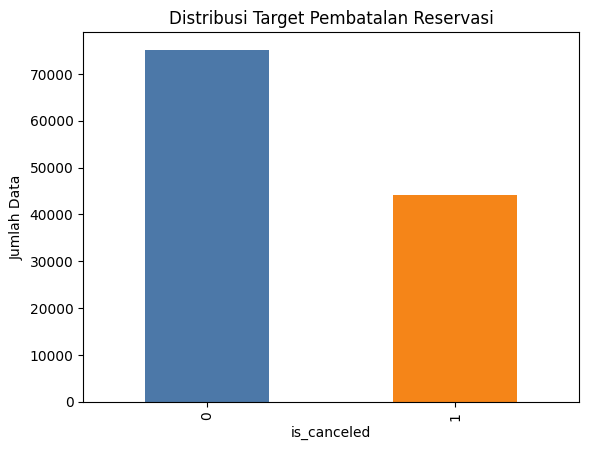


Ringkasan kolom numerik:


,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0



Jumlah nilai unik kolom kategorikal:


reservation_status_date    926
country                    177
arrival_date_month          12
assigned_room_type          12
reserved_room_type          10
market_segment               8
meal                         5
distribution_channel         5
customer_type                4
deposit_type                 3
reservation_status           3
hotel                        2
dtype: int64


Rasio pembatalan berdasarkan tipe hotel:


is_canceled,0,1
hotel,,
City Hotel,0.5827,0.4173
Resort Hotel,0.7224,0.2776



Rata-rata lead time berdasarkan target:


is_canceled
0     79.98
1    144.85
Name: lead_time, dtype: float64

In [3]:
print("Ukuran dataset:", df.shape)
print("Jumlah data duplikat:", df.duplicated().sum())

print("\nMissing values:")
missing_values = df.isna().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0])

print("\nDistribusi target:")
target_distribution = df[TARGET_COLUMN].value_counts().sort_index().rename("count")
target_proportion = df[TARGET_COLUMN].value_counts(normalize=True).sort_index().rename("proportion")
display(pd.concat([target_distribution, target_proportion], axis=1))

ax = target_distribution.plot(kind="bar", color=["#4c78a8", "#f58518"])
ax.set_title("Distribusi Target Pembatalan Reservasi")
ax.set_xlabel("is_canceled")
ax.set_ylabel("Jumlah Data")
plt.show()

print("\nRingkasan kolom numerik:")
display(df.select_dtypes(include="number").describe().T)

print("\nJumlah nilai unik kolom kategorikal:")
categorical_columns_eda = df.select_dtypes(exclude="number").columns
display(df[categorical_columns_eda].nunique().sort_values(ascending=False))

print("\nRasio pembatalan berdasarkan tipe hotel:")
display(pd.crosstab(df["hotel"], df[TARGET_COLUMN], normalize="index").round(4))

print("\nRata-rata lead time berdasarkan target:")
display(df.groupby(TARGET_COLUMN)["lead_time"].mean().round(2))

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
clean_df = df.copy()

# Kolom ini mengandung leakage karena dibuat setelah status reservasi diketahui.
clean_df = clean_df.drop(columns=["reservation_status", "reservation_status_date"], errors="ignore")

# Menangani missing values pada kolom yang paling relevan.
if "children" in clean_df.columns:
    clean_df["children"] = clean_df["children"].fillna(0)
if "agent" in clean_df.columns:
    clean_df["agent"] = clean_df["agent"].fillna(0)
if "company" in clean_df.columns:
    clean_df["company"] = clean_df["company"].fillna(0)
if "country" in clean_df.columns:
    clean_df["country"] = clean_df["country"].fillna("Unknown")

# Feature engineering sederhana.
clean_df["total_stay_nights"] = clean_df["stays_in_weekend_nights"] + clean_df["stays_in_week_nights"]
clean_df["total_guests"] = clean_df["adults"] + clean_df["children"] + clean_df["babies"]
clean_df["room_changed"] = (clean_df["reserved_room_type"] != clean_df["assigned_room_type"]).astype(int)
clean_df["has_special_need"] = (
    (clean_df["total_of_special_requests"] > 0) | (clean_df["required_car_parking_spaces"] > 0)
).astype(int)

# Penanganan outlier dan data tidak valid.
clean_df = clean_df[clean_df["adr"].between(0, 1000)]
clean_df = clean_df[clean_df["total_guests"] > 0]
clean_df[TARGET_COLUMN] = clean_df[TARGET_COLUMN].astype(int)

x = clean_df.drop(columns=[TARGET_COLUMN])
y = clean_df[TARGET_COLUMN]

numeric_columns = x.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_columns = [column for column in x.columns if column not in numeric_columns]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_columns),
        ("cat", categorical_pipeline, categorical_columns),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)
feature_names = list(preprocessor.get_feature_names_out())

train_processed = pd.DataFrame(x_train_processed, columns=feature_names)
train_processed[TARGET_COLUMN] = y_train.reset_index(drop=True)

test_processed = pd.DataFrame(x_test_processed, columns=feature_names)
test_processed[TARGET_COLUMN] = y_test.reset_index(drop=True)

train_processed.to_csv(OUTPUT_DIR / "train_preprocessed.csv", index=False, float_format="%.6g")
test_processed.to_csv(OUTPUT_DIR / "test_preprocessed.csv", index=False, float_format="%.6g")
joblib.dump(preprocessor, OUTPUT_DIR / "preprocessor.joblib")
(OUTPUT_DIR / "feature_names.txt").write_text("\n".join(feature_names), encoding="utf-8")

metadata = {
    "raw_rows": int(len(df)),
    "clean_rows": int(len(clean_df)),
    "train_rows": int(len(train_processed)),
    "test_rows": int(len(test_processed)),
    "target_column": TARGET_COLUMN,
    "numeric_columns": numeric_columns,
    "categorical_columns": categorical_columns,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
}
(OUTPUT_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("Preprocessing selesai.")
print(f"Raw rows: {len(df)}")
print(f"Clean rows: {len(clean_df)}")
print(f"Train shape: {train_processed.shape}")
print(f"Test shape: {test_processed.shape}")
print("File output:")
for output_file in sorted(OUTPUT_DIR.iterdir()):
    print("-", output_file)

Preprocessing selesai.
Raw rows: 119390
Clean rows: 119208
Train shape: (95366, 255)
Test shape: (23842, 255)
File output:
- namadataset_preprocessing\feature_names.txt
- namadataset_preprocessing\metadata.json
- namadataset_preprocessing\preprocessor.joblib
- namadataset_preprocessing\README.md
- namadataset_preprocessing\test_preprocessed.csv
- namadataset_preprocessing\train_preprocessed.csv
